In [16]:
import netrd
import networkx as nx
import numpy as np
import random
import math
from zlib import crc32
import pandas as pd
import matplotlib.pyplot as plt
from itertools import combinations

# Assignment 4

### Question 1

In [64]:
G_1 = nx.erdos_renyi_graph(64, 0.2)

Xs = []

for seed in range(20):
    np.random.seed(seed)
    random.seed(seed)

    D0 = netrd.dynamics.IsingGlauber()
    X = D0.simulate(G_1, L=1000)
    X = X.astype(float)

    Xs.append(X)

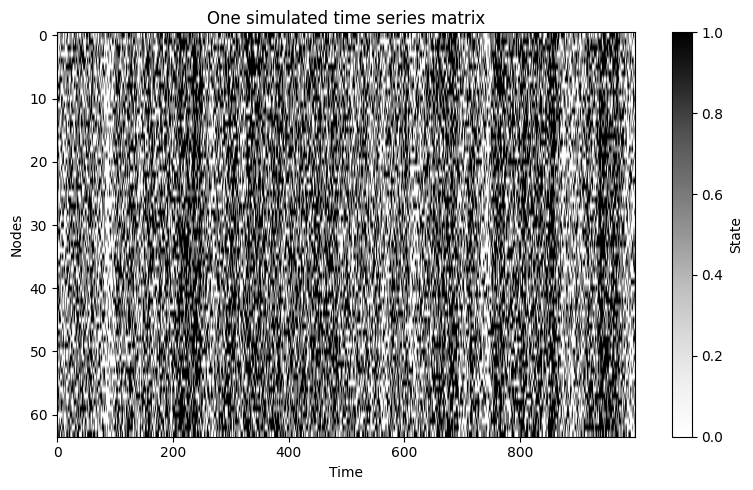

In [67]:
X0 = Xs[1]

plt.figure(figsize=(8, 5))
plt.imshow(X0, aspect='auto', cmap='Greys')
plt.xlabel('Time')
plt.ylabel('Nodes')
plt.title('One simulated time series matrix')
plt.colorbar(label='State')
plt.tight_layout()
plt.show()

For the underlying random graph, I used an Erdős–Rényi (ER) model with edge probability 𝑝=0.2. As the dynamical process, I adopted the Ising–Glauber model. The Ising model exhibits stochastic spin-flip dynamics driven by thermal noise, where each node’s state probabilistically aligns with its neighbors. This introduces randomness into the system, leading to time series that appear noisy rather than fully synchronized.

From the heatmap, we observe that node states fluctuate at a high frequency over time. This behavior arises because the ER graph has a homogeneous and unstructured topology—connections are distributed randomly without strong communities or hubs—so there is no dominant structural pattern to enforce large-scale coordination among nodes.

In [70]:
Rs = []

for i, X in enumerate(Xs):
    recon = netrd.reconstruction.CorrelationMatrix()
    R = recon.fit(X)
    Rs.append(R)

In [71]:
Rs_d = []

for i, X in enumerate(Xs):
    recon = netrd.reconstruction.FreeEnergyMinimization()
    out = recon.fit(X,threshold_type='degree',avg_k=avg_k_G)
    Rs_d.append(out)

In [76]:
def edge_difference_count(G1, G2):
    E1 = set(tuple(sorted(e)) for e in G1.edges())
    E2 = set(tuple(sorted(e)) for e in G2.edges())
    return len(E1.symmetric_difference(E2))


def D_graph(G1, G2):
    n = G1.number_of_nodes()
    total_pairs = n * (n - 1) // 2
    return edge_difference_count(G1, G2) / total_pairs

D_values = [D_graph(G_1, R) for R in Rs_d]

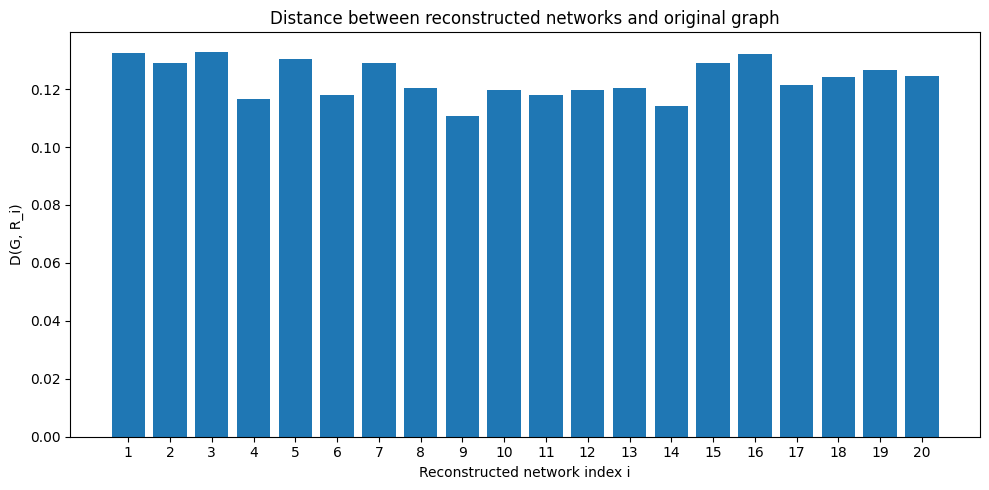

In [78]:
plt.figure(figsize=(10, 5))
plt.bar(range(1, 21), D_values)

plt.xlabel("Reconstructed network index i")
plt.ylabel("D(G, R_i)")
plt.title("Distance between reconstructed networks and original graph")

plt.xticks(range(1, 21))
plt.tight_layout()
plt.show()

To assess the correctness of each reconstructed network, my metric $D(G,R)$ is based on the symmetric difference between the edge sets of the original graph $G$ and the reconstructed graph $R$. Specifically:

$D(G,R) = \frac{|E(G) \triangle E(R)|}{\binom{n}{2}}$

where $E(G)$ and $E(R)$ denote the edge sets of the original and reconstructed graphs, respectively; $\triangle$ represents the symmetric difference; and $\binom{n}{2}$ denotes the total number of all possible undirected edges among $n$ labeled nodes.

This metric quantifies the proportion of node pairs for which the edge status differs between graph $G$ and graph $R$. It encompasses the following two scenarios:

False Positives: Edges that appear in $R$ but not in $G$;
False Negatives: Edges that exist in $G$ but are missing from $R$.

A smaller value of $D(G,R)$ indicates that the reconstructed graph is closer to the original graph; conversely, a larger value signifies a greater reconstruction error.

Subsequently, I calculated the corresponding $D(G,R_i)$ values ​​for 20 thresholded reconstructed networks $R_i$ and visualized the results in a bar chart. These values ​​are clustered within a relatively narrow range, roughly spanning from 0.11 to 0.13. This suggests that across the 20 independent simulations, the reconstruction process demonstrated a remarkably high degree of consistency: although the specific realizations of the time series generated in each simulation varied, the error levels of the resulting reconstructed networks—relative to the true graph—remained highly similar.

As evident from the figure, no single reconstruction result performed significantly better or worse than the others. Instead, the error remained remarkably stable across all runs, indicating that the reconstruction method possesses reasonable robustness under the currently established conditions. Meanwhile, across all 20 cases, the values ​​of the distance function $D(G, R_i)$ were consistently and significantly greater than zero. This fact indicates that the reconstruction results were not flawless; a substantial number of edges were still misidentified. In other words, while this method is capable of recovering most of the features of the original structure, it is not yet able to reconstruct the original graph—which serves as the "ground truth"—with complete precision.

Overall, this distance function provides a simple and easily interpretable means of quantifying reconstruction quality, as it directly measures the discrepancies in edge composition between the reconstructed network and the original network.

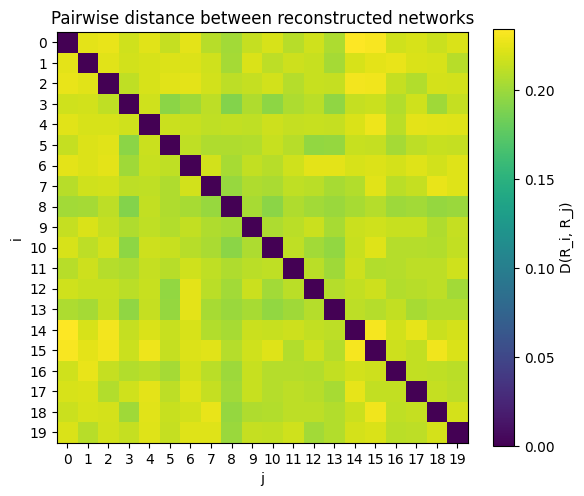

In [79]:
n = len(Rs_d)
d_matrix = np.zeros((n, n))

for i in range(n):
    for j in range(n):
        d_matrix[i, j] = D_graph(Rs_d[i], Rs_d[j])
plt.figure(figsize=(6, 5))
plt.imshow(d_matrix, cmap='viridis', interpolation='nearest')

plt.colorbar(label="D(R_i, R_j)")
plt.title("Pairwise distance between reconstructed networks")
plt.xlabel("j")
plt.ylabel("i")

plt.xticks(range(n))
plt.yticks(range(n))

plt.tight_layout()
plt.show()

In the examples I have cited, because the Erdős–Rényi (ER) graph exhibits no distinct clustering or community structure, the time series generated by Ising–Glauber dynamics display a high degree of randomness, and the structural signals embedded within them are extremely faint. Consequently, the observed fluctuations in node states are frequent, and they lack the robust, persistent correlations that would clearly reflect the underlying network topology.

When applying the "Free Energy Minimization" reconstruction method—an approach based on inferring pairwise interactions from statistical dependencies within the data—the algorithm is often compelled to rely on signals that are relatively weak and heavily contaminated by noise. This results in significant discrepancies between the reconstructed network and the original graph, as many of the inferred edges are, in reality, artifacts of noise rather than products of genuine structural relationships.

### Question 2

In [3]:
class BloomFilter:
    
    def __init__(self, n: int, e: float):
        self.n = n
        self.e = e
        self.k = 3
        self.m = math.ceil(-(n * math.log(e)) / (math.log(2) ** 2))
        self.k = max(1, round((self.m / n) * math.log(2)))
        self.bits = bytearray(self.m)
    def _bloom_hash(self, edge, i):
        u, v = edge
        return crc32(f"{i}{u}{v}".encode("utf-8"))
        
    def add(self, edge):
        for i in range(self.k):
            pos = self._bloom_hash(edge, i) % self.m
            self.bits[pos] = 1
            
    def query(self, edge):
        for i in range(self.k):
            pos = self._bloom_hash(edge, i) % self.m
            if self.bits[pos] == 0:
                return False
        return True


In [15]:
ER_G = nx.erdos_renyi_graph(1000,0.05)

In [45]:
nx.number_of_edges(ER_G)


25437

In [43]:
def evaluate_bloom_filter(G, e):
    """
    Build a Bloom filter for graph G with error rate e,
    then test all possible edges.
    Returns： a dictionary of performance statistics.
    """
    num_edges = G.number_of_edges()
    n_nodes = G.number_of_nodes()

    bf = BloomFilter(n=num_edges, e=e)
    for u, v in G.edges():
        bf.add((u, v))

    edge_set = set((min(u, v), max(u, v)) for u, v in G.edges())
    all_possible_edges = combinations(range(n_nodes), 2)

    bf_positive_count = 0
    true_edges_count = 0
    false_positive_count = 0

    for edge in all_possible_edges:
        in_bf = bf.query(edge)
        in_graph = edge in edge_set

        if in_bf:
            bf_positive_count += 1
            if in_graph:
                true_edges_count += 1
            else:
                false_positive_count += 1

    total_possible_edges = n_nodes * (n_nodes - 1) // 2
    print("Time without Bloom filter: ", total_possible_edges, "e =",e)
    print("False positives: ", false_positive_count, "e =",e)
    print("Bloom positives: ", bf_positive_count, "e =",e)
    
    return None

In [44]:
e_list = [0.01, 0.05, 0.1] 
for e in e_list:
    evaluate_bloom_filter(ER_G, e)


Time without Bloom filter:  499500 e = 0.01
False positives:  5106 e = 0.01
Bloom positives:  30543 e = 0.01
Time without Bloom filter:  499500 e = 0.05
False positives:  23945 e = 0.05
Bloom positives:  49382 e = 0.05
Time without Bloom filter:  499500 e = 0.1
False positives:  48038 e = 0.1
Bloom positives:  73475 e = 0.1


In [47]:
def generate_edge_pool(num_nodes):
    return list(combinations(range(num_nodes), 2))
    
def test_bloom_over_capacity(n_design=10000,e=0.01,actual_multiplier=1.5,num_nodes=1500):
    
    edge_pool = generate_edge_pool(num_nodes)
    actual_count = int(n_design * actual_multiplier)
    inserted_edges = set(random.sample(edge_pool, actual_count))
    remaining_edges = list(set(edge_pool) - inserted_edges)

    # Build Bloom filter using only n_design
    bf = BloomFilter(n=n_design, e=e)

    for edge in inserted_edges:
        bf.add(edge)

    bf_positive_count = 0
    true_edges_count = 0
    false_positive_count = 0
    for edge in edge_pool:
        in_bf = bf.query(edge)
        in_graph = edge in inserted_edges

        if in_bf:
            bf_positive_count += 1
            if in_graph:
                true_edges_count += 1
            else:
                false_positive_count += 1

    return {
        "e": e,
        "n_design": n_design,
        "actual_count": actual_count,
        "multiplier": actual_multiplier,
        "False_positives": false_positive_count,
        "Bloom_positives": bf_positive_count
    }

In [48]:
e_list = (0.01,0.05,0.1)
n_design=10000
multipliers = (1.5, 2.0, 2.5, 3.0)
results = []

for e in e_list:
    for mult in multipliers:
        result = test_bloom_over_capacity(
            n_design=n_design,
            e=e,
            actual_multiplier=mult,
            num_nodes=1500
        )
        results.append(result)

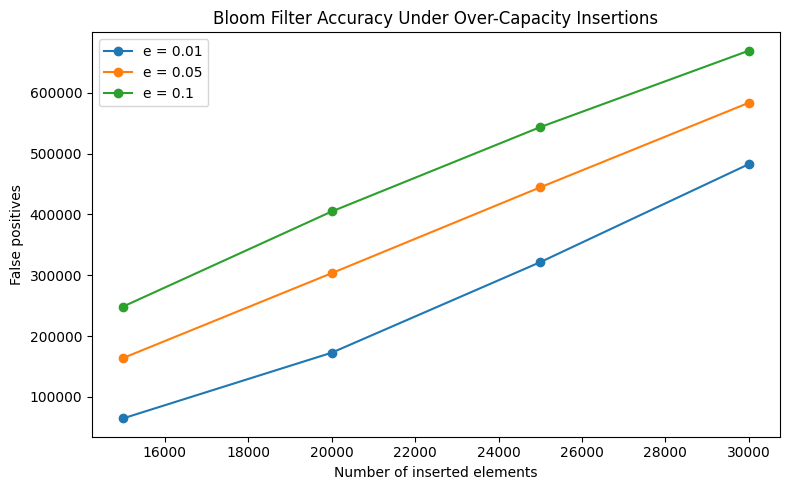

In [52]:
df = pd.DataFrame(results)
plt.figure(figsize=(8, 5))

for e in sorted(df["e"].unique()):
    sub = df[df["e"] == e].sort_values("actual_count")
    plt.plot(sub["actual_count"], sub["False_positives"], marker="o", label=f"e = {e}")

plt.xlabel("Number of inserted elements")
plt.ylabel("False positives")
plt.title("Bloom Filter Accuracy Under Over-Capacity Insertions")
plt.legend()
plt.tight_layout()
plt.show()

# Question 3

In [1]:
import numpy as np

# ============================================================
# PART 1. NK LANDSCAPE GENERATOR
# ============================================================

def generate_nk_landscape(N=20, K=5, seed=None, apply_paper_skew=True):
    """
    Create one NK landscape and return a fitness function on binary strings.

    This is the "environment" or "problem space" that agents search over.
    It does NOT implement the agent-based model itself. It only defines
    how good or bad each binary-string solution is.

    --------------------------------------------------------------------
    BIG PICTURE
    --------------------------------------------------------------------
    In an NK landscape:
        - N is the length of the binary string.
        - K controls ruggedness.

    Each solution is a binary string such as:
        (0, 1, 1, 0, 0, 1, ...)

    The score of a solution is built from N local contributions.
    Each local contribution depends on:
        - the bit at one locus i
        - and K other loci that interact with it

    As K increases, the landscape usually becomes more rugged:
        - more local optima
        - more path dependence
        - more chance of getting stuck

    --------------------------------------------------------------------
    CONNECTION TO LAZER & FRIEDMAN (2007)
    --------------------------------------------------------------------
    This follows the standard NK setup described in Appendix A of the paper.

    The paper:
        - uses an NK landscape as the search environment,
        - normalizes performance by the maximum of the landscape,
        - and discusses an r^8 monotonic transformation in Appendix A.

    This function:
        1. builds the local dependency structure,
        2. creates random contribution tables,
        3. computes the score of every possible bitstring,
        4. normalizes by the exact global maximum,
        5. optionally applies the paper-style r^8 transformation.

    --------------------------------------------------------------------
    IMPORTANT DISTINCTION
    --------------------------------------------------------------------
    This function only builds the landscape. It does NOT: create agents, create a graph, etc.

    Those belong to the ABM code that you will write.

    --------------------------------------------------------------------
    PARAMETERS
    --------------------------------------------------------------------
    N : int
        Length of the bitstring.

    K : int
        Number of partner loci that affect each locus.
        Must satisfy K < N.

    seed : int or None
        Random seed for reproducibility.

    apply_paper_skew : bool
        If True, apply the paper's monotonic r^8 transformation after
        normalization by the global maximum.

    --------------------------------------------------------------------
    RETURNS
    --------------------------------------------------------------------
    landscape : dict
        Contains:
            - "fitness_fn": callable that scores a bitstring
            - "N", "K"
            - "partners": dependency structure
            - "tables": local NK contribution tables
            - "raw_scores": raw NK scores over all 2^N states
            - "normalized_scores": raw_scores / max(raw_scores)
            - "scores": final scores after optional r^8 transform
            - "global_max_raw": exact maximum raw score
            - "global_best_bits": one bitstring attaining the max

    --------------------------------------------------------------------
    COMPUTATIONAL NOTE
    --------------------------------------------------------------------
    This version explicitly enumerates all 2^N states.

    That is feasible for N = 20:
        2^20 = 1,048,576 states

    That is one reason N = 20 is still manageable here.
    """

    if K >= N:
        raise ValueError("K must be less than N.")

    rng = np.random.default_rng(seed)

    def bits_to_int(bits):
        """
        Convert a bitstring into an integer index.

        Example:
            (0,0,0) -> 0
            (0,0,1) -> 1
            (0,1,0) -> 2
            ...
        """
        x = 0
        for b in bits:
            x = (x << 1) | int(b)
        return x

    def int_to_bits(x, N):
        """
        Convert an integer back into an N-bit tuple.
        """
        return tuple((x >> shift) & 1 for shift in range(N - 1, -1, -1))

    # ------------------------------------------------------------
    # Step 1: choose K partner loci for each locus i
    # ------------------------------------------------------------
    partners = []
    for i in range(N):
        others = [j for j in range(N) if j != i]
        chosen = tuple(rng.choice(others, size=K, replace=False))
        partners.append(chosen)

    # ------------------------------------------------------------
    # Step 2: create random local contribution tables
    # Each locus gets a table with 2^(K+1) entries
    # ------------------------------------------------------------
    tables = []
    for i in range(N):
        table = rng.random(2 ** (K + 1))
        tables.append(table)

    # ------------------------------------------------------------
    # Step 3: enumerate all 2^N possible solutions
    # ------------------------------------------------------------
    num_states = 2 ** N
    states = np.arange(num_states, dtype=np.uint32)[:, None]
    shifts = np.arange(N - 1, -1, -1, dtype=np.uint32)
    bit_matrix = ((states >> shifts) & 1).astype(np.uint8)

    # ------------------------------------------------------------
    # Step 4: compute raw NK score for every state
    # ------------------------------------------------------------
    raw_scores = np.zeros(num_states, dtype=np.float64)

    for i in range(N):
        # The local contribution for locus i depends on:
        #   - bit i itself
        #   - the K partner bits chosen for i
        idxs = (i,) + partners[i]
        local_bits = bit_matrix[:, idxs]

        # Convert each local bit-pattern into an integer lookup index
        local_powers = (1 << np.arange(K, -1, -1)).astype(np.uint32)
        table_indices = (local_bits * local_powers).sum(axis=1)

        raw_scores += tables[i][table_indices]

    raw_scores /= N

    # ------------------------------------------------------------
    # Step 5: normalize by the exact global maximum
    # ------------------------------------------------------------
    global_max_raw = float(raw_scores.max())
    normalized_scores = raw_scores / global_max_raw

    # ------------------------------------------------------------
    # Step 6: optional paper-style skew transformation
    # ------------------------------------------------------------
    if apply_paper_skew:
        scores = normalized_scores ** 8
    else:
        scores = normalized_scores.copy()

    argmax_state = int(raw_scores.argmax())
    global_best_bits = int_to_bits(argmax_state, N)

    def fitness_fn(bits):
        """
        Return the final fitness score of one bitstring.
        """
        idx = bits_to_int(bits)
        return float(scores[idx])

    return {
        "fitness_fn": fitness_fn,
        "N": N,
        "K": K,
        "partners": partners,
        "tables": tables,
        "raw_scores": raw_scores,
        "normalized_scores": normalized_scores,
        "scores": scores,
        "global_max_raw": global_max_raw,
        "global_best_bits": global_best_bits,
    }

In [2]:
def one_bit_mutation(bits, rng=None):
    """
    Input:
    bits: tuple/list, e.g., (1, 0, 1, 1, 0)
    rng: NumPy random generator
    
    Output:
    A new tuple with one randomly flipped bit
    """
    if rng is None:
        rng = np.random.default_rng()

    bits = list(bits)
    idx = rng.integers(0, len(bits))   
    bits[idx] = 1 - bits[idx]          
    return tuple(bits)
def make_linear_network(n_agents):
    network = []
    for i in range(n_agents):
        neighbors = []
        if i > 0:
            neighbors.append(i - 1)
        if i < n_agents - 1:
            neighbors.append(i + 1)
        network.append(neighbors)
    return network
def make_fully_connected_network(n_agents):
    network = []
    for i in range(n_agents):
        neighbors = [j for j in range(n_agents) if j != i]
        network.append(neighbors)
    return network

In [7]:
def synchronous_update(current_solutions, network, fitness_fn, seed=None):
    """
    Inputs:
    current_solutions: list of binary tuples
    e.g., [(0,1,1,0), (1,0,1,1), ...]
    network: Adjacency list
    fitness_fn: The fitness function returned by generate_nk_landscape
    rng: NumPy random generator
    
    Output:
    next_solutions: Solutions after synchronous updating
    """
    if seed is None:
        rng = np.random.default_rng()
    else:
        rng = np.random.default_rng(seed)
    n_agents = len(current_solutions)

    current_fitness = [fitness_fn(sol) for sol in current_solutions]
    next_solutions = current_solutions.copy()

    for i in range(n_agents):
        my_solution = current_solutions[i]
        my_fitness = current_fitness[i]
        neighbors = network[i]

        # Step 1: Check whether there is a strictly superior neighbor.
        better_neighbors = []
        for j in neighbors:
            if current_fitness[j] > my_fitness:
                better_neighbors.append(j)

        # Step 2: If a superior neighbor exists, copy the one with the highest fitness.
        if len(better_neighbors) > 0:
            best_fitness = max(current_fitness[j] for j in better_neighbors)

            best_neighbors = [
                j for j in better_neighbors
                if current_fitness[j] == best_fitness
            ]

            chosen_j = rng.choice(best_neighbors) 
            next_solutions[i] = current_solutions[chosen_j]

        # Step 3: one-bit mutation
        else:
            mutated = one_bit_mutation(my_solution, rng)
            mutated_fitness = fitness_fn(mutated)

            if mutated_fitness > my_fitness:
                next_solutions[i] = mutated
            else:
                next_solutions[i] = my_solution

    return next_solutions

In [8]:
def compute_population_metrics(population, fitness_fn):
    """
    input:
        population: list of binary tuples
        fitness_fn: NK landscape fitness function

    output:
        avg_fitness
        best_fitness
        num_unique
    """
    fitness_values = [fitness_fn(sol) for sol in population]
    avg_fitness = np.mean(fitness_values)
    best_fitness = np.max(fitness_values)
    num_unique = len(set(population))

    return avg_fitness, best_fitness, num_unique

In [6]:
def make_initial_population(n_agents, N, seed=None):
    if seed is None:
        rng = np.random.default_rng()
    else:
        rng = np.random.default_rng(seed)
    return [tuple(rng.integers(0, 2, size=N)) for _ in range(n_agents)]

In [13]:
def run_single_simulation(initial_population, network, fitness_fn, T=100, seed=None):
    if seed is None:
        rng = np.random.default_rng()
    else:
        rng = np.random.default_rng(seed)
    population = initial_population.copy()

    avg_fitness_series = []
    best_fitness_series = []
    unique_series = []

    avg_fit, best_fit, num_unique = compute_population_metrics(population, fitness_fn)
    avg_fitness_series.append(avg_fit)
    best_fitness_series.append(best_fit)
    unique_series.append(num_unique)

    for _ in range(T):
        population = synchronous_update(population, network, fitness_fn, seed = seed)
        avg_fit, best_fit, num_unique = compute_population_metrics(population, fitness_fn)
        avg_fitness_series.append(avg_fit)
        best_fitness_series.append(best_fit)
        unique_series.append(num_unique)

    return {
        "avg_fitness": np.array(avg_fitness_series),
        "best_fitness": np.array(best_fitness_series),
        "num_unique": np.array(unique_series),
    }

In [14]:
n_agents = 100
N = 20
K = 5
T = 100
seed = 123


landscape = generate_nk_landscape(N=N, K=K, seed=seed)
fitness_fn = landscape["fitness_fn"]

initial_population = make_initial_population(n_agents=n_agents, N=N, seed=seed)

path_graph = make_linear_network(n_agents)
complete_graph = make_fully_connected_network(n_agents)

path_results = run_single_simulation(
    initial_population=initial_population,
    network=path_graph,
    fitness_fn=fitness_fn,
    T=T,
    seed = seed
)

complete_results = run_single_simulation(
    initial_population=initial_population,
    network=complete_graph,
    fitness_fn=fitness_fn,
    T=T,
    seed = seed
)

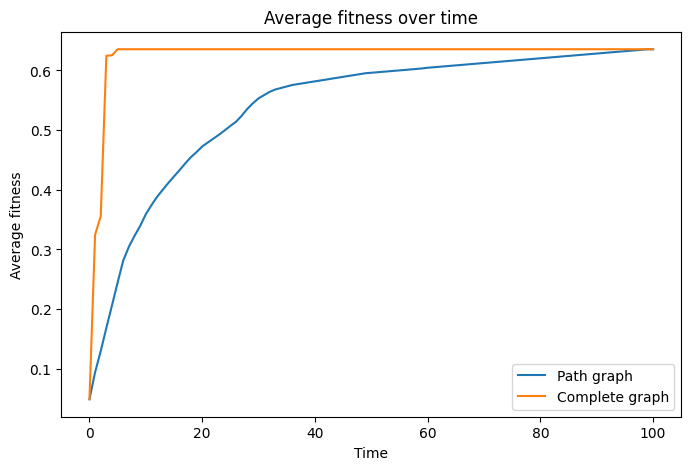

In [17]:
t = np.arange(T + 1)

plt.figure(figsize=(8, 5))
plt.plot(t, path_results["avg_fitness"], label="Path graph")
plt.plot(t, complete_results["avg_fitness"], label="Complete graph")
plt.xlabel("Time")
plt.ylabel("Average fitness")
plt.title("Average fitness over time")
plt.legend()
plt.show()

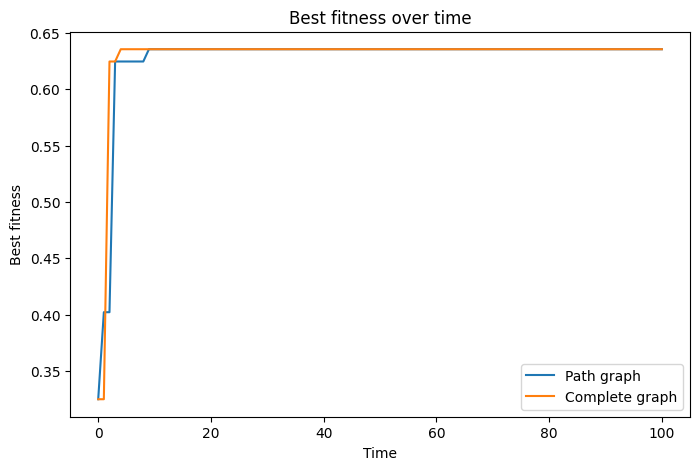

In [18]:
plt.figure(figsize=(8, 5))
plt.plot(t, path_results["best_fitness"], label="Path graph")
plt.plot(t, complete_results["best_fitness"], label="Complete graph")
plt.xlabel("Time")
plt.ylabel("Best fitness")
plt.title("Best fitness over time")
plt.legend()
plt.show()

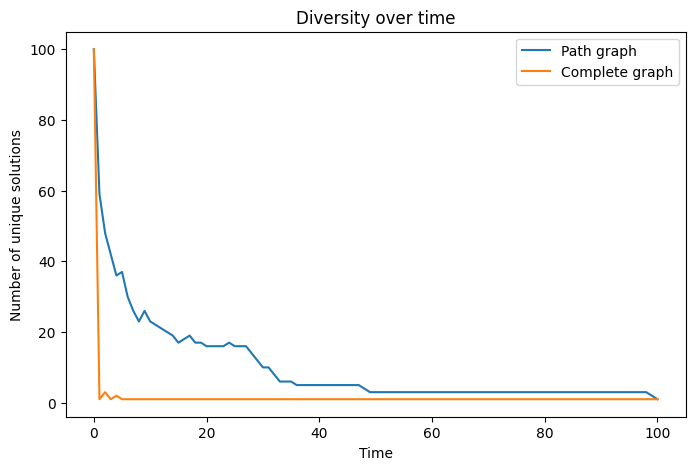

In [23]:
run_times = 100
n_agents = 100
N = 20
K = 5
T = 100
seed = 123

all_path_results = []
all_complete_results = []

for i in range(run_times):
    Tseed = seed + 1000 * i

    landscape = generate_nk_landscape(N=N, K=K, seed=Tseed)
    fitness_fn = landscape["fitness_fn"]

    initial_population = make_initial_population(
        n_agents=n_agents,
        N=N,
        seed=Tseed
    )

    path_graph = make_linear_network(n_agents)
    complete_graph = make_fully_connected_network(n_agents)

    path_results = run_single_simulation(
        initial_population=initial_population,
        network=path_graph,
        fitness_fn=fitness_fn,
        T=T,
        seed=Tseed
    )

    complete_results = run_single_simulation(
        initial_population=initial_population,
        network=complete_graph,
        fitness_fn=fitness_fn,
        T=T,
        seed=Tseed
    )

    all_path_results.append(path_results)
    all_complete_results.append(complete_results)

In [24]:
path_avg = np.array([res["avg_fitness"] for res in all_path_results])
complete_avg = np.array([res["avg_fitness"] for res in all_complete_results])

path_unique = np.array([res["num_unique"] for res in all_path_results])
complete_unique = np.array([res["num_unique"] for res in all_complete_results])
def summarize_results(x):
    mean = x.mean(axis=0)
    sd = x.std(axis=0, ddof=1)
    se = sd / np.sqrt(x.shape[0])
    lower = mean - 1.96 * se
    upper = mean + 1.96 * se
    return mean, lower, upper
path_avg_mean, path_avg_lo, path_avg_hi = summarize_results(path_avg)
complete_avg_mean, complete_avg_lo, complete_avg_hi = summarize_results(complete_avg)

path_unique_mean, path_unique_lo, path_unique_hi = summarize_results(path_unique)
complete_unique_mean, complete_unique_lo, complete_unique_hi = summarize_results(complete_unique)

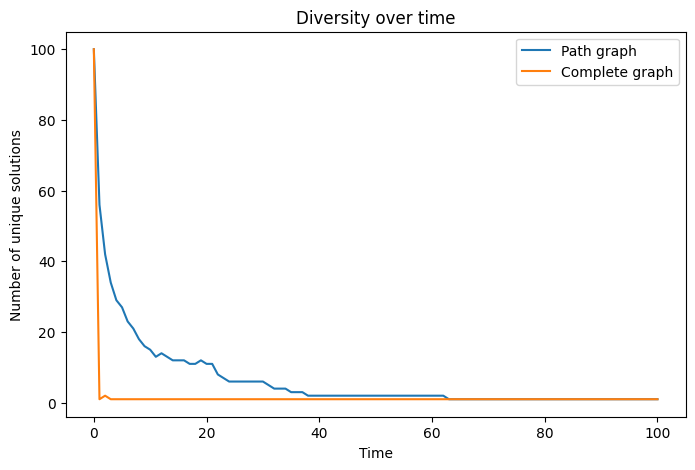

In [36]:
plt.figure(figsize=(8, 5))
plt.plot(t, path_results["num_unique"], label="Path graph")
plt.plot(t, complete_results["num_unique"], label="Complete graph")
plt.xlabel("Time")
plt.ylabel("Number of unique solutions")
plt.title("Diversity over time")
plt.legend()
plt.show()

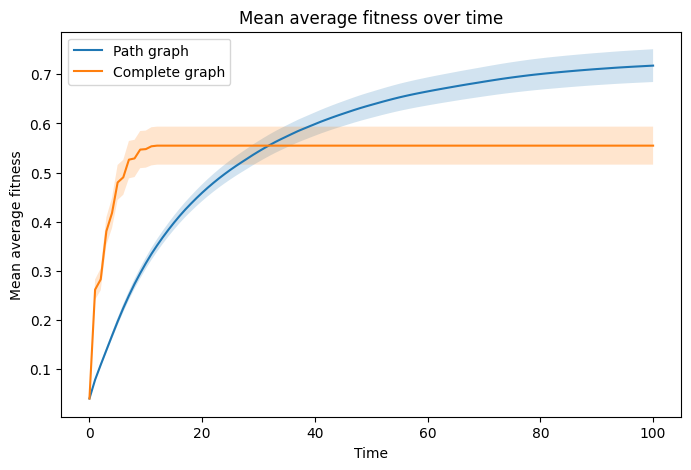

In [25]:
t = np.arange(T + 1)

plt.figure(figsize=(8, 5))
plt.plot(t, path_avg_mean, label="Path graph")
plt.plot(t, complete_avg_mean, label="Complete graph")

plt.fill_between(t, path_avg_lo, path_avg_hi, alpha=0.2)
plt.fill_between(t, complete_avg_lo, complete_avg_hi, alpha=0.2)

plt.xlabel("Time")
plt.ylabel("Mean average fitness")
plt.title("Mean average fitness over time")
plt.legend()
plt.show()

In [32]:
run_times = 100
n_agents = 100
N = 20
K = 5
T = 100
seed = 123
K_v = [0, 1, 5, 10]
result_K = []
for K in K_v:
    all_path_results = []
    all_complete_results = []
    
    for i in range(run_times):
        Tseed = seed + 100 * i
    
        landscape = generate_nk_landscape(N=N, K=K, seed=Tseed)
        fitness_fn = landscape["fitness_fn"]
    
        initial_population = make_initial_population(
            n_agents=n_agents,
            N=N,
            seed=Tseed
        )
    
        path_graph = make_linear_network(n_agents)
        complete_graph = make_fully_connected_network(n_agents)
    
        path_results = run_single_simulation(
            initial_population=initial_population,
            network=path_graph,
            fitness_fn=fitness_fn,
            T=T,
            seed=Tseed
        )
    
        complete_results = run_single_simulation(
            initial_population=initial_population,
            network=complete_graph,
            fitness_fn=fitness_fn,
            T=T,
            seed=Tseed
        )
    
        all_path_results.append(path_results)
        all_complete_results.append(complete_results)
    path_avg = np.array([res["avg_fitness"] for res in all_path_results])
    complete_avg = np.array([res["avg_fitness"] for res in all_complete_results])

    path_longrun = path_avg[:, T]
    complete_longrun = complete_avg[:, T]

    result_K.append({"K":K,
                     "diff_mean": complete_longrun.mean() - path_longrun.mean(),
                    })
    

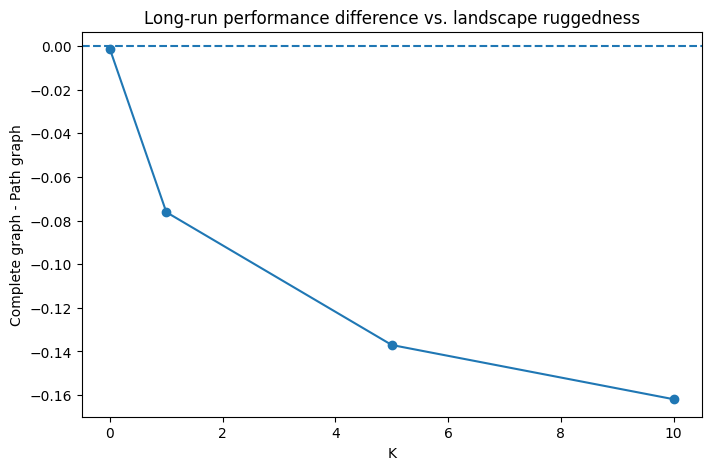

In [34]:
Ks = [d["K"] for d in result_K]
diffs = [d["diff_mean"] for d in result_K]

plt.figure(figsize=(8, 5))
plt.plot(Ks, diffs, marker="o")
plt.axhline(0, linestyle="--")
plt.xlabel("K")
plt.ylabel("Complete graph - Path graph")
plt.title("Long-run performance difference vs. landscape ruggedness")
plt.show()